##Daily Challenge: Analyzing the IMDB Movie Dataset with Matplotlib and Seaborn

In [7]:
import pandas as pd

# Load and  Inspect Data

df = pd.read_csv("/content/drive/MyDrive/BootGenAI/imdb_top_1000.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB
None


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [11]:
# Data preprocessing

print(df.isna().sum())
print(df.shape)

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64
(1000, 16)


In [13]:
#Certificate (101 manquants)
df["Certificate"] = df["Certificate"].fillna("Unknown")

#Meta_score (157 manquants)
df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].median())

#Gross (169 manquants)
df["Gross"] = df["Gross"].str.replace(",", "").astype(float)
df["Gross"] = df["Gross"].fillna(0)


In [14]:
# Convert Released_Year to numeric
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

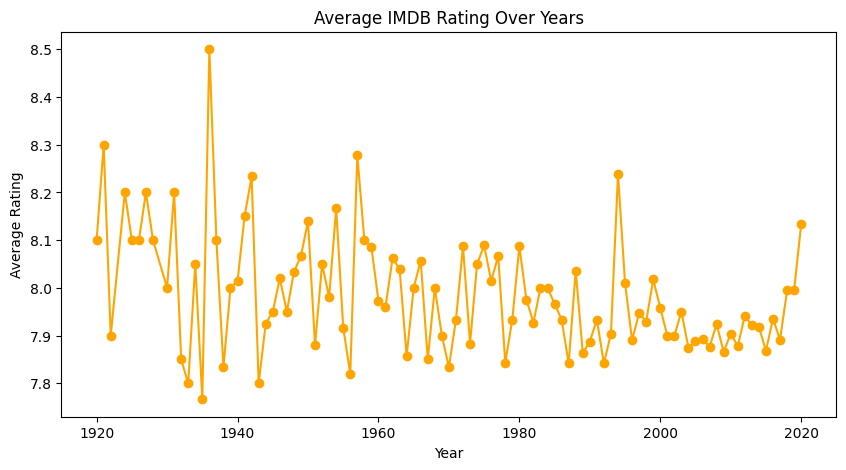

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

#Rating Trends Over Years
plt.figure(figsize=(10,5))
df.groupby("Released_Year")["IMDB_Rating"].mean().plot(kind="line", marker="o", color = 'orange')
plt.title("Average IMDB Rating Over Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

/tmp/ipython-input-80533583.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")


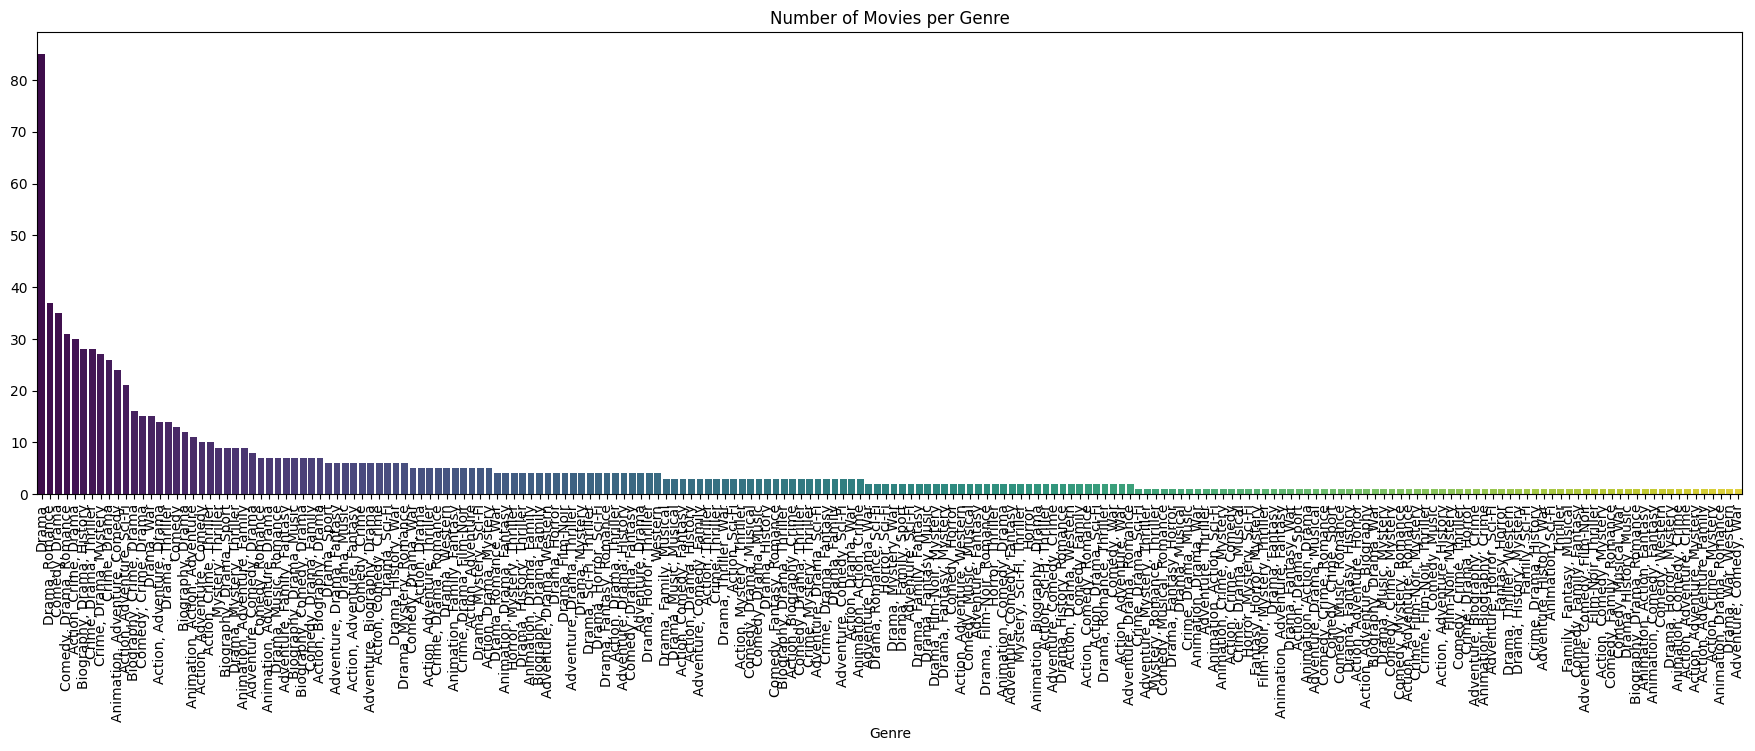

In [22]:
#Genre Popularity Analysis
plt.figure(figsize=(22,6))
genre_counts = df["Genre"].value_counts()
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Number of Movies per Genre")
plt.show()

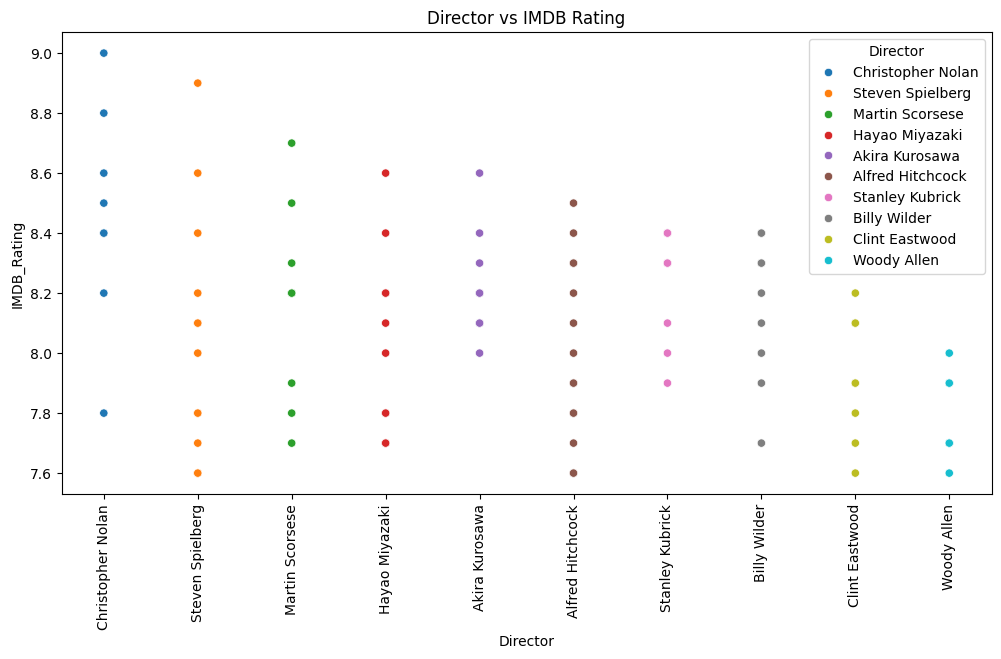

In [23]:
#Director’s Impact on Ratings
plt.figure(figsize=(12,6))
top_directors = df["Director"].value_counts().head(10).index
sns.scatterplot(data=df[df["Director"].isin(top_directors)], x="Director", y="IMDB_Rating", hue="Director", palette="tab10")
plt.xticks(rotation=90)
plt.title("Director vs IMDB Rating")
plt.show()

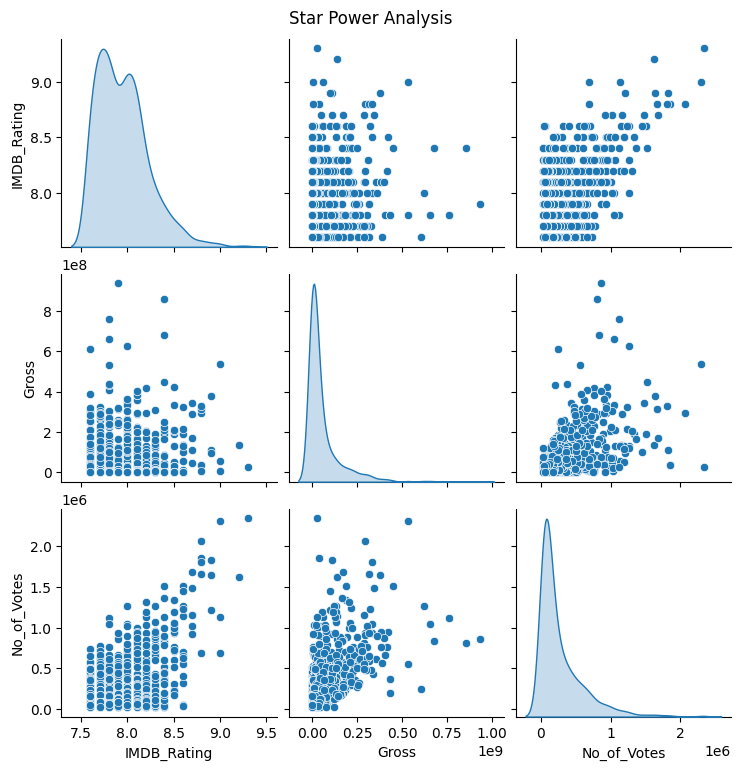

In [24]:
#Focus on numeric columns + stars
sns.pairplot(df[["IMDB_Rating", "Gross", "No_of_Votes"]], diag_kind="kde")
plt.suptitle("Star Power Analysis", y=1.02)
plt.show()

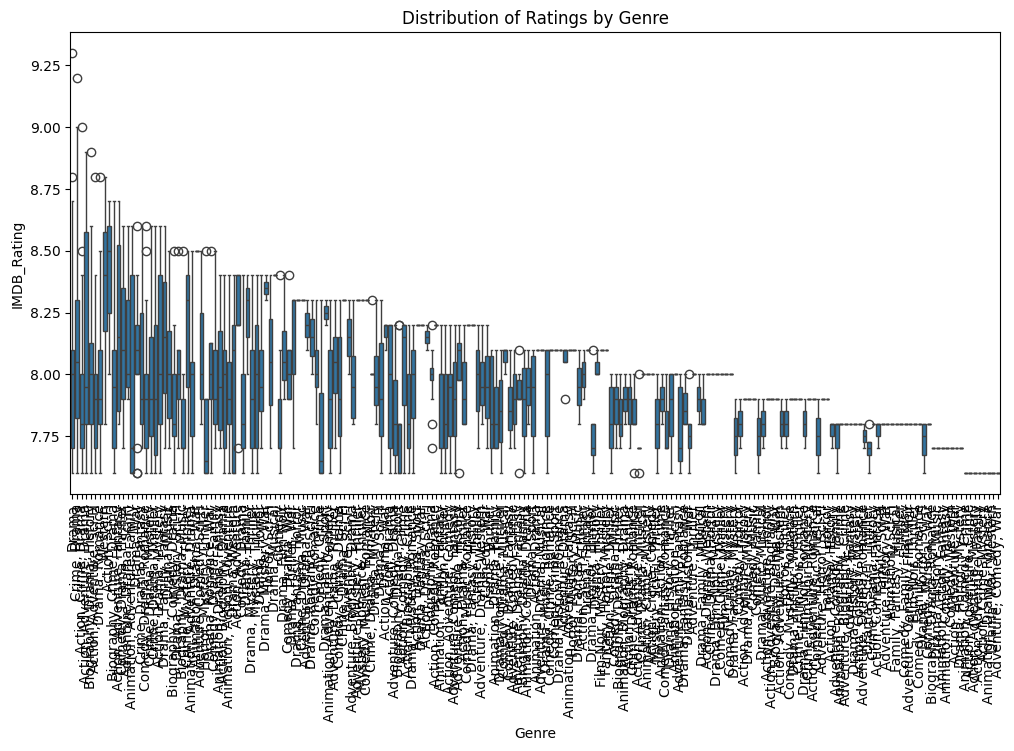

In [25]:
#Box Plot of Genres vs Ratings
plt.figure(figsize=(12,6))
sns.boxplot(x="Genre", y="IMDB_Rating", data=df)
plt.xticks(rotation=90)
plt.title("Distribution of Ratings by Genre")
plt.show()

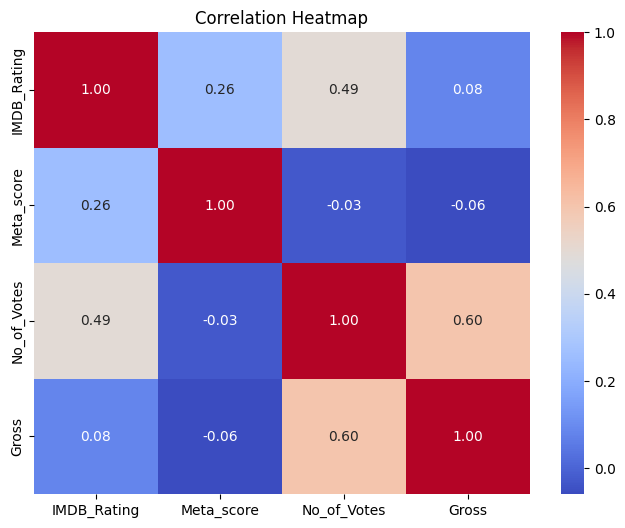

In [26]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
corr = df[["IMDB_Rating", "Meta_score", "No_of_Votes", "Gross"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()